In [1]:
r = 32
r

32

In [5]:
import os 

In [6]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit\\research'

In [7]:
os.chdir('../')

In [8]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit'

In [9]:
# ── Cell 1 — imports & path setup ───────────────────────────────────
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from config.configuration import load_config
from src.constants import (
    RAW_DATA_FILE,
    PROCESSED_DATA_FILE,
    TARGET_COLUMN,
    TARGET_MAPPING,
    MISSING_VALUE_TOKEN,
    PROTECTED_ATTRIBUTES,
)
from src.utils import (
    get_dataframe_info,
    validate_columns,
    save_dataframe,
)
from src import get_logger

logger = get_logger("research.data_ingestion")
CONFIG = load_config()

print("✅ Imports successful")
print(f"   Config source   : {CONFIG.data.source}")
print(f"   Raw path        : {RAW_DATA_FILE}")
print(f"   Processed path  : {PROCESSED_DATA_FILE}")
print(f"   Protected attrs : {PROTECTED_ATTRIBUTES}")

✅ Imports successful
   Config source   : scikit-learn/adult-census-income
   Raw path        : data\raw\adult_income.csv
   Processed path  : data\processed\clean.csv
   Protected attrs : ['sex', 'race', 'marital.status']


In [10]:
# ── Cell 2 — download raw dataset ───────────────────────────────────
from datasets import load_dataset

raw_path = Path(RAW_DATA_FILE)

if raw_path.exists():
    logger.info(f"Cache found — loading from {raw_path}")
    df_raw = pd.read_csv(raw_path)
else:
    logger.info("No cache — downloading from HuggingFace...")
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    ds = load_dataset(CONFIG.data.source, split=CONFIG.data.split)
    df_raw = ds.to_pandas()
    df_raw.to_csv(raw_path, index=False)
    logger.info(f"Saved to {raw_path}")

print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head()

d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-05-05 16:45:51] INFO research.data_ingestion - No cache — downloading from HuggingFace...


d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rajve\.cache\huggingface\hub\datasets--scikit-learn--adult-census-income. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 32561/32561 [00:00<00:00, 161766.32 examples/s]


[2026-05-05 16:45:56] INFO research.data_ingestion - Saved to data\raw\adult_income.csv
Shape   : (32561, 15)
Columns : ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [11]:
# ── Cell 3 — raw data info ───────────────────────────────────────────
info = get_dataframe_info(df_raw)

print("── Shape ──────────────────────────────")
print(f"  Rows    : {info['shape'][0]:,}")
print(f"  Columns : {info['shape'][1]}")

print("\n── Dtypes ─────────────────────────────")
for col, dtype in info["dtypes"].items():
    print(f"  {col:<30} {dtype}")

print("\n── Null counts ────────────────────────")
nulls = {k: v for k, v in info["null_counts"].items() if v > 0}
if nulls:
    for col, count in nulls.items():
        print(f"  {col:<30} {count}")
else:
    print("  No null values found")

print(f"\n── Duplicate rows : {info['duplicate_rows']}")

── Shape ──────────────────────────────
  Rows    : 32,561
  Columns : 15

── Dtypes ─────────────────────────────
  age                            int64
  workclass                      str
  fnlwgt                         int64
  education                      str
  education.num                  int64
  marital.status                 str
  occupation                     str
  relationship                   str
  race                           str
  sex                            str
  capital.gain                   int64
  capital.loss                   int64
  hours.per.week                 int64
  native.country                 str
  income                         str

── Null counts ────────────────────────
  No null values found

── Duplicate rows : 24


In [12]:
# ── Cell 4 — inspect missing value token "?" ────────────────────────
print(f"Checking for missing value token: '{MISSING_VALUE_TOKEN}'\n")

question_mark_counts = (df_raw == MISSING_VALUE_TOKEN).sum()
affected = question_mark_counts[question_mark_counts > 0]

if len(affected) > 0:
    print("Columns containing '?':")
    for col, count in affected.items():
        pct = count / len(df_raw) * 100
        print(f"  {col:<30} {count:>5} rows  ({pct:.2f}%)")
else:
    print("No '?' tokens found")

total_affected = (df_raw == MISSING_VALUE_TOKEN).any(axis=1).sum()
print(f"\nTotal rows with at least one '?' : {total_affected:,}")
print(f"Percentage of dataset            : {total_affected/len(df_raw)*100:.2f}%")

Checking for missing value token: '?'

Columns containing '?':
  workclass                       1836 rows  (5.64%)
  occupation                      1843 rows  (5.66%)
  native.country                   583 rows  (1.79%)

Total rows with at least one '?' : 2,399
Percentage of dataset            : 7.37%


Target column : 'income'
Unique values : ['<=50K', '>50K']

Value counts:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


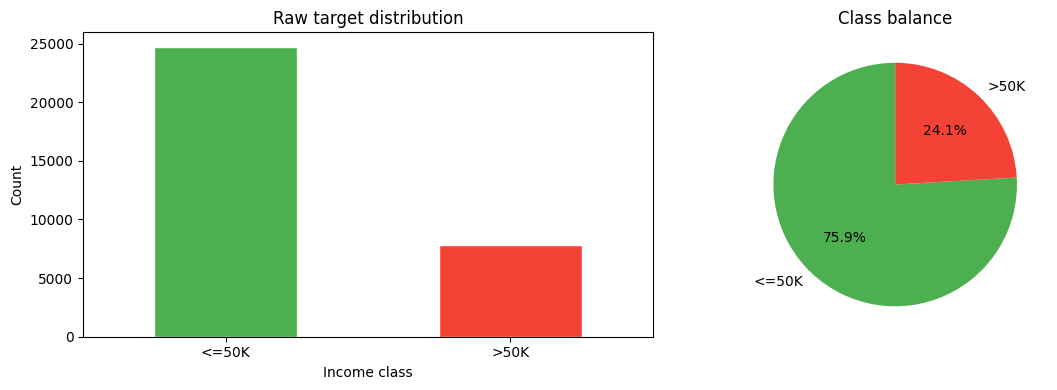


Imbalance ratio : 3.15x


In [13]:
# ── Cell 5 — target column distribution ─────────────────────────────
print(f"Target column : '{TARGET_COLUMN}'")
print(f"Unique values : {df_raw[TARGET_COLUMN].unique().tolist()}")
print(f"\nValue counts:")
print(df_raw[TARGET_COLUMN].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# raw labels
df_raw[TARGET_COLUMN].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#4CAF50", "#F44336"],
    edgecolor="white"
)
axes[0].set_title("Raw target distribution")
axes[0].set_xlabel("Income class")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# class imbalance ratio
counts = df_raw[TARGET_COLUMN].value_counts()
axes[1].pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#F44336"],
    startangle=90
)
axes[1].set_title("Class balance")

plt.tight_layout()
plt.show()

imbalance = counts.max() / counts.min()
print(f"\nImbalance ratio : {imbalance:.2f}x")

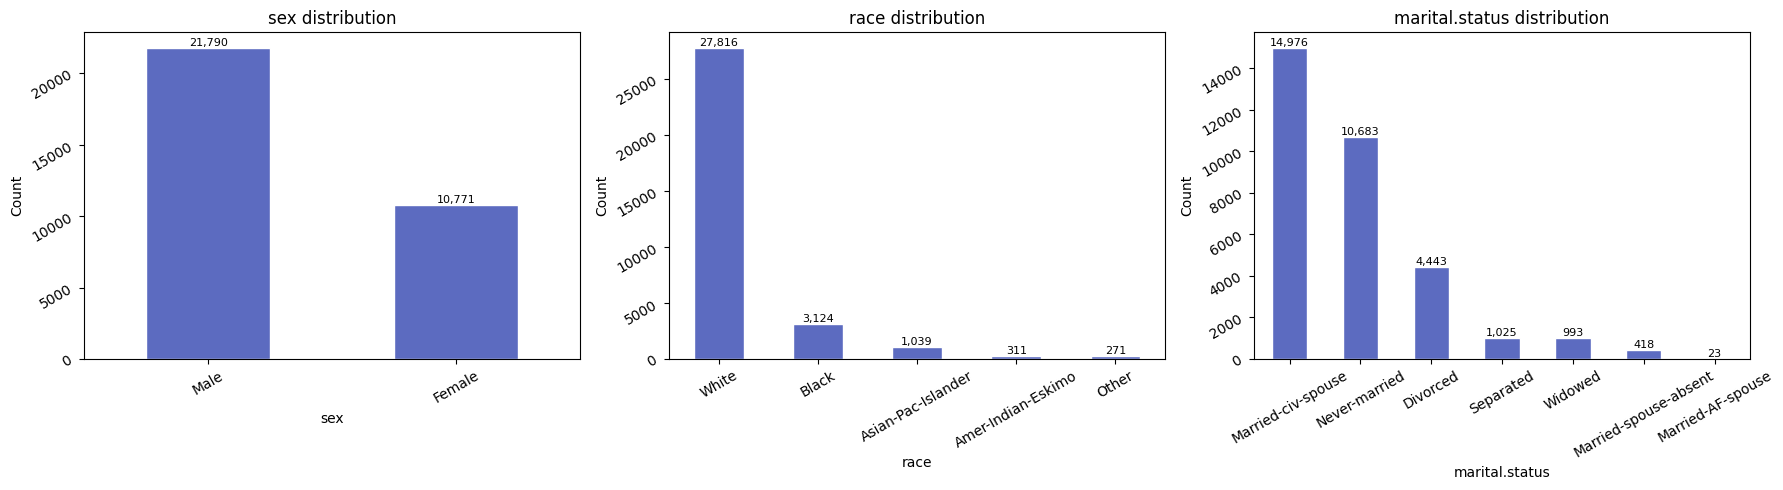


sex:
  Male                                21,790  (66.9%)
  Female                              10,771  (33.1%)

race:
  White                               27,816  (85.4%)
  Black                                3,124  (9.6%)
  Asian-Pac-Islander                   1,039  (3.2%)
  Amer-Indian-Eskimo                     311  (1.0%)
  Other                                  271  (0.8%)

marital.status:
  Married-civ-spouse                  14,976  (46.0%)
  Never-married                       10,683  (32.8%)
  Divorced                             4,443  (13.6%)
  Separated                            1,025  (3.1%)
  Widowed                                993  (3.0%)
  Married-spouse-absent                  418  (1.3%)
  Married-AF-spouse                       23  (0.1%)


In [14]:
# ── Cell 6 — protected attribute distributions ───────────────────────
fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                          figsize=(6 * len(PROTECTED_ATTRIBUTES), 5))

if len(PROTECTED_ATTRIBUTES) == 1:
    axes = [axes]

for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
    counts = df_raw[attr].value_counts()
    counts.plot(kind="bar", ax=ax, edgecolor="white", color="#5C6BC0")
    ax.set_title(f"{attr} distribution")
    ax.set_xlabel(attr)
    ax.set_ylabel("Count")
    ax.tick_params(rotation=30)
    for bar in ax.patches:
        ax.annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

for attr in PROTECTED_ATTRIBUTES:
    print(f"\n{attr}:")
    vc = df_raw[attr].value_counts()
    for val, count in vc.items():
        print(f"  {str(val):<35} {count:>6,}  ({count/len(df_raw)*100:.1f}%)")

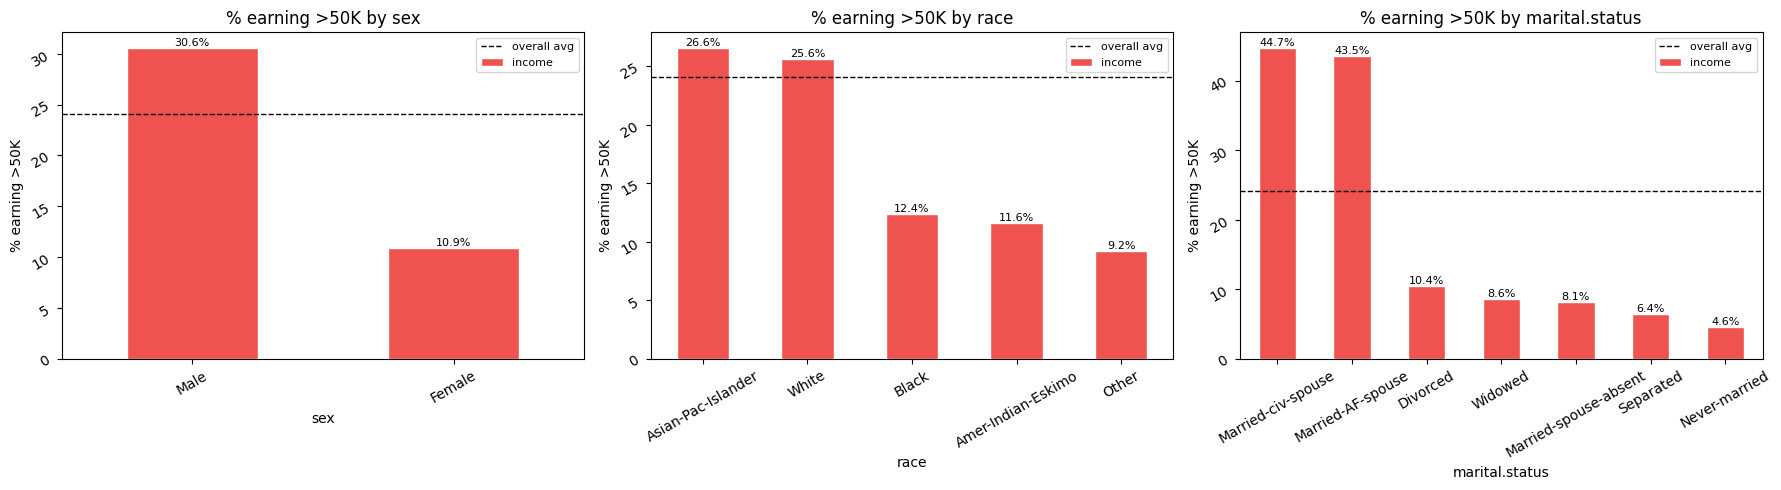

In [15]:
# ── Cell 7 — income rate per protected attribute ─────────────────────
fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                          figsize=(6 * len(PROTECTED_ATTRIBUTES), 5))

if len(PROTECTED_ATTRIBUTES) == 1:
    axes = [axes]

df_temp = df_raw.copy()
df_temp[TARGET_COLUMN] = df_temp[TARGET_COLUMN].str.strip()

for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
    income_rate = (
        df_temp.groupby(attr)[TARGET_COLUMN]
        .apply(lambda x: (x == ">50K").mean() * 100)
        .sort_values(ascending=False)
    )
    income_rate.plot(kind="bar", ax=ax, color="#EF5350", edgecolor="white")
    ax.set_title(f"% earning >50K by {attr}")
    ax.set_ylabel("% earning >50K")
    ax.tick_params(rotation=30)
    ax.axhline(
        y=(df_temp[TARGET_COLUMN] == ">50K").mean() * 100,
        color="black", linestyle="--", linewidth=1,
        label="overall avg"
    )
    ax.legend(fontsize=8)
    for bar in ax.patches:
        ax.annotate(
            f"{bar.get_height():.1f}%",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

In [16]:
# ── Cell 8 — clean data ──────────────────────────────────────────────
df_clean = df_raw.copy()

# strip whitespace
df_clean = df_clean.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)

# encode target
df_clean[TARGET_COLUMN] = df_clean[TARGET_COLUMN].map(TARGET_MAPPING)
print(f"Target after encoding : {df_clean[TARGET_COLUMN].unique().tolist()}")

# drop missing value rows
before = len(df_clean)
df_clean = df_clean.replace(MISSING_VALUE_TOKEN, None).dropna()
dropped = before - len(df_clean)
print(f"Rows dropped          : {dropped:,}  ({dropped/before*100:.2f}%)")
print(f"Clean shape           : {df_clean.shape}")

df_clean = df_clean.reset_index(drop=True)
df_clean.head()

Target after encoding : [0, 1]
Rows dropped          : 2,399  (7.37%)
Clean shape           : (30162, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,0
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,0


Feature correlations with income (numeric only):

  education.num                  +0.3353  █████████████
  age                            +0.2420  █████████
  hours.per.week                 +0.2295  █████████
  capital.gain                   +0.2212  ████████
  capital.loss                   +0.1501  ██████
  fnlwgt                         -0.0090  


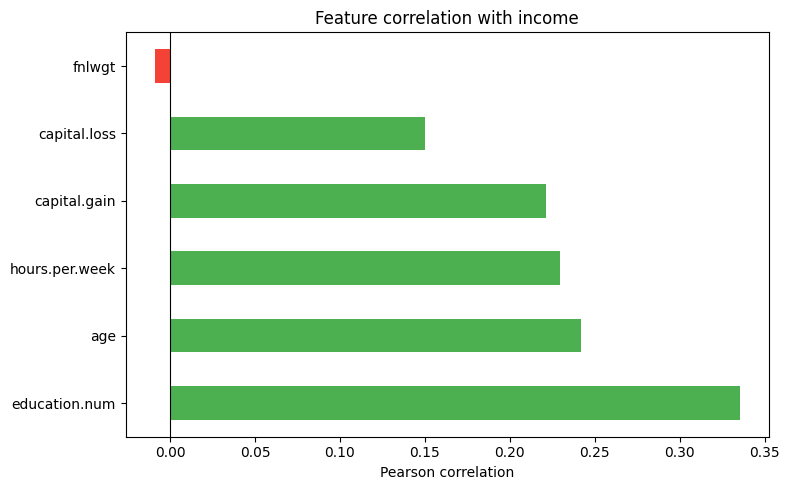

In [18]:
# ── Cell 10 — feature correlations with target ───────────────────────
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()

correlations = (
    df_clean[numeric_cols]
    .corr()[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(ascending=False)
)

print("Feature correlations with income (numeric only):\n")
for feat, corr in correlations.items():
    bar = "█" * int(abs(corr) * 40)
    sign = "+" if corr >= 0 else "-"
    print(f"  {feat:<30} {sign}{abs(corr):.4f}  {bar}")

plt.figure(figsize=(8, 5))
correlations.plot(kind="barh", color=[
    "#4CAF50" if v >= 0 else "#F44336"
    for v in correlations
])
plt.title("Feature correlation with income")
plt.xlabel("Pearson correlation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
# ── Cell 11 — save processed data ───────────────────────────────────
processed_path = Path(PROCESSED_DATA_FILE)
processed_path.parent.mkdir(parents=True, exist_ok=True)

save_dataframe(df_clean, str(processed_path))

print(f"Saved to    : {processed_path}")
print(f"Final shape : {df_clean.shape}")
print(f"File size   : {processed_path.stat().st_size / 1024:.1f} KB")

[2026-05-05 16:51:19] INFO src.utils.common - DataFrame saved: data\processed\clean.csv — shape: (30162, 15)
Saved to    : data\processed\clean.csv
Final shape : (30162, 15)
File size   : 3139.7 KB


In [21]:
# ── Cell 12 — summary ────────────────────────────────────────────────
try:
    print("=" * 55)
    print("   DATA INGESTION RESEARCH — SUMMARY")
    print("=" * 55)

    # ── validate both files exist before summary ─────────────────
    if not Path(RAW_DATA_FILE).exists():
        raise FileNotFoundError(
            f"Raw data file not found: {RAW_DATA_FILE}\n"
            f"  → Re-run Cell 2 to download the dataset"
        )

    if not Path(PROCESSED_DATA_FILE).exists():
        raise FileNotFoundError(
            f"Processed data file not found: {PROCESSED_DATA_FILE}\n"
            f"  → Re-run Cell 11 to save processed data"
        )

    # ── validate dataframes are loaded in memory ─────────────────
    if "df_raw" not in dir() or df_raw is None:
        raise NameError(
            "df_raw not found in memory\n"
            "  → Re-run Cell 2 to load raw data"
        )

    if "df_clean" not in dir() or df_clean is None:
        raise NameError(
            "df_clean not found in memory\n"
            "  → Re-run Cell 8 to clean data"
        )

    # ── validate target column is encoded ────────────────────────
    if df_clean[TARGET_COLUMN].dtype == "object":
        raise TypeError(
            f"Target column '{TARGET_COLUMN}' is still a string.\n"
            f"  → Re-run Cell 8 to encode target"
        )

    # ── compute stats ─────────────────────────────────────────────
    raw_rows      = len(df_raw)
    clean_rows    = len(df_clean)
    dropped_rows  = raw_rows - clean_rows
    drop_pct      = dropped_rows / raw_rows * 100
    n_features    = df_clean.shape[1] - 1
    n_neg         = (df_clean[TARGET_COLUMN] == 0).sum()
    n_pos         = (df_clean[TARGET_COLUMN] == 1).sum()
    balance_ratio = n_neg / n_pos
    file_size_kb  = Path(PROCESSED_DATA_FILE).stat().st_size / 1024

    # ── print summary ─────────────────────────────────────────────
    print(f"  Raw rows          : {raw_rows:,}")
    print(f"  Clean rows        : {clean_rows:,}")
    print(f"  Rows dropped      : {dropped_rows:,}  ({drop_pct:.2f}%)")
    print(f"  Features          : {n_features}")
    print(f"  Target balance    : {n_neg:,} neg / {n_pos:,} pos "
          f"  (ratio {balance_ratio:.2f}x)")
    print(f"  Protected attrs   : {PROTECTED_ATTRIBUTES}")
    print(f"  Output saved to   : {PROCESSED_DATA_FILE}")
    print(f"  File size         : {file_size_kb:.1f} KB")
    print("=" * 55)

    # ── warn if class imbalance is high ───────────────────────────
    if balance_ratio > 3.0:
        logger.warning(
            f"High class imbalance detected — ratio {balance_ratio:.2f}x. "
            f"Consider oversampling or class weights in model training."
        )

    # ── warn if too many rows were dropped ────────────────────────
    if drop_pct > 10.0:
        logger.warning(
            f"{drop_pct:.2f}% of rows dropped during cleaning. "
            f"Review missing value handling in Cell 8."
        )

    logger.info("Data ingestion research complete ✅")
    print("\n  Next → open prepare_base_model.ipynb")

except FileNotFoundError as e:
    logger.error(f"File not found:\n  {e}")
    print(f"\n❌ FileNotFoundError: {e}")

except NameError as e:
    logger.error(f"Variable not found in memory:\n  {e}")
    print(f"\n❌ NameError: {e}")

except TypeError as e:
    logger.error(f"Data type issue:\n  {e}")
    print(f"\n❌ TypeError: {e}")

except KeyError as e:
    logger.error(f"Column not found in DataFrame: {e}")
    print(f"\n❌ KeyError — column missing: {e}")
    print(f"   Available columns: {df_clean.columns.tolist()}")

except Exception as e:
    logger.exception(f"Unexpected error in summary cell: {e}")
    print(f"\n❌ Unexpected error: {type(e).__name__}: {e}")
    print("   Check logs/ for full traceback")

   DATA INGESTION RESEARCH — SUMMARY
  Raw rows          : 32,561
  Clean rows        : 30,162
  Rows dropped      : 2,399  (7.37%)
  Features          : 14
  Target balance    : 22,654 neg / 7,508 pos   (ratio 3.02x)
  Protected attrs   : ['sex', 'race', 'marital.status']
  Output saved to   : data\processed\clean.csv
  File size         : 3139.7 KB
[2026-05-05 16:55:24] WARNING research.data_ingestion - High class imbalance detected — ratio 3.02x. Consider oversampling or class weights in model training.
[2026-05-05 16:55:24] INFO research.data_ingestion - Data ingestion research complete ✅

  Next → open prepare_base_model.ipynb


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 86: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap